In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D_gan
from utils.loss_functions import recon_loss
from models.alzheimers_cure_2d import VAE
from models.alzheiminator_3d import Discriminator3D, Generator3D
from models.MiniEncoder3D import MiniEncoder3D, PhiFeatureExtractor

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


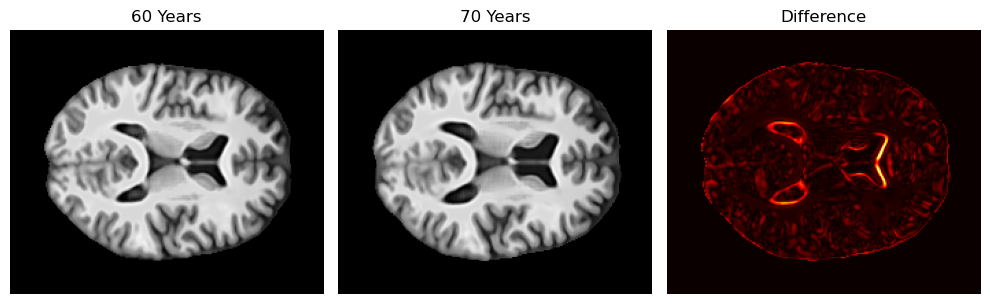

In [4]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## Combined Dice + Volumetric Difference Loss

The `combined_dice_volume_loss` combines two complementary loss functions:
1. **Dice Loss**: Measures the overlap between predicted and target probability maps
2. **Volumetric Difference Loss**: Penalizes differences in total volume between predictions and targets

This is useful for 3D medical image segmentation/reconstruction tasks where both spatial overlap and volume preservation are important.

In [8]:
base_enc = MiniEncoder3D(in_ch=1, chs=(16,32,64,128))   # Can swap with pretrained encoder
phi = PhiFeatureExtractor(base_enc).to(device)

G = Generator3D(in_channels=1, out_channels=1).to(device)
G.load_state_dict(torch.load("out/mpgan_3d/3d_mpgan_G_4.2.pt"))
D = Discriminator3D(in_channels=1).to(device)
D.load_state_dict(torch.load("out/mpgan_3d/3d_mpgan_D_4.2.pt"))

<All keys matched successfully>

In [ ]:
# Use with fit_3D
G, D, snapshots = fit_3D_gan(
    G=G,
    D=D,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    epochs=16001,
    save_every=400,
    print_every=400,
    phi=phi,
)


output_dir = "out/mpgan_3d"
os.makedirs(output_dir, exist_ok=True)
model_path1 = os.path.join(output_dir, "3d_mpgan_D_4.4.pt")
torch.save(D.state_dict(), model_path1)
print(f"Model saved to {model_path1}")

model_path2 = os.path.join(output_dir, "3d_mpgan_G_4.4.pt")
torch.save(G.state_dict(), model_path2)
print(f"Model saved to {model_path2}")

[Iter 0] D_total=0.7175 G_total=12.8502 L1=0.0105 Perc=0.4621 AdvG=1.0355
Saved snapshot at iter 0
[Iter 400] D_total=0.6342 G_total=12.3929 L1=0.0125 Perc=0.4515 AdvG=0.7940
Saved snapshot at iter 400
[Iter 800] D_total=0.6818 G_total=12.4753 L1=0.0102 Perc=0.4591 AdvG=0.7418
Saved snapshot at iter 800
[Iter 1200] D_total=0.7029 G_total=12.3106 L1=0.0098 Perc=0.4341 AdvG=1.2135
Saved snapshot at iter 1200
[Iter 1600] D_total=0.6695 G_total=11.5028 L1=0.0114 Perc=0.4255 AdvG=0.5792
Saved snapshot at iter 1600
[Iter 2000] D_total=0.7016 G_total=12.8026 L1=0.0109 Perc=0.4689 AdvG=0.8087
Saved snapshot at iter 2000
[Iter 2400] D_total=0.6605 G_total=12.1514 L1=0.0089 Perc=0.4459 AdvG=0.7820
Saved snapshot at iter 2400
[Iter 2800] D_total=0.6629 G_total=12.2321 L1=0.0096 Perc=0.4538 AdvG=0.6485
Saved snapshot at iter 2800
[Iter 3200] D_total=0.6804 G_total=12.8130 L1=0.0141 Perc=0.4728 AdvG=0.6396
Saved snapshot at iter 3200


Displaying snapshot from pair 0


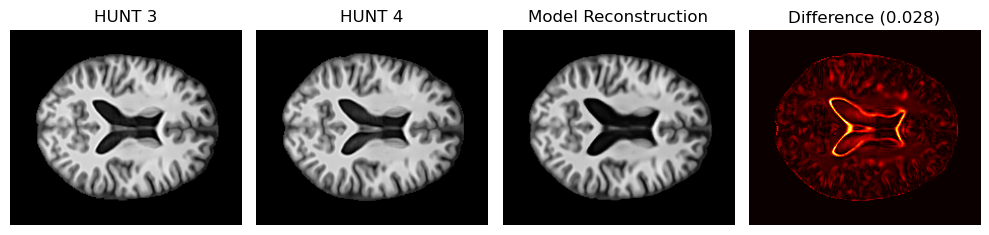

Displaying snapshot from pair 400


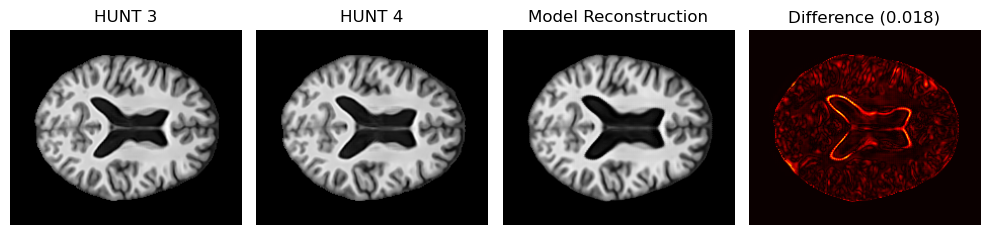

Displaying snapshot from pair 800


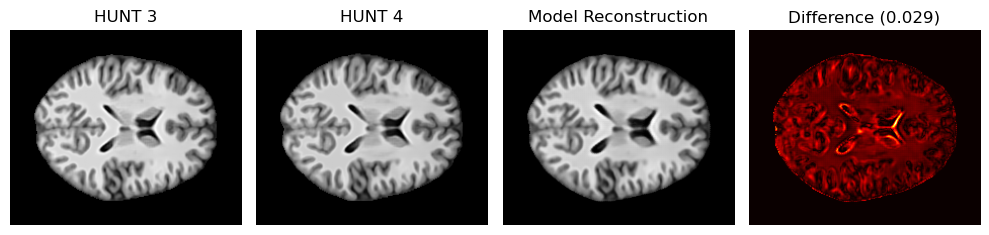

Displaying snapshot from pair 1200


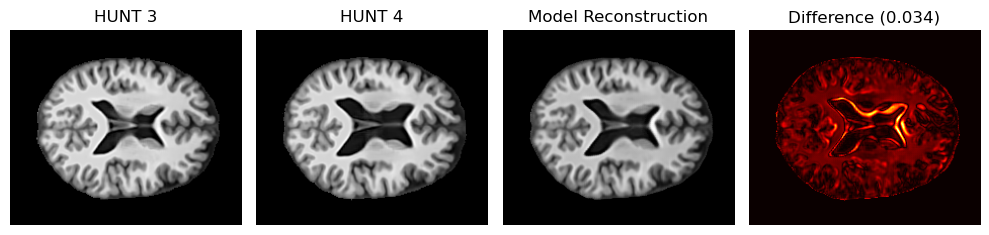

Displaying snapshot from pair 1600


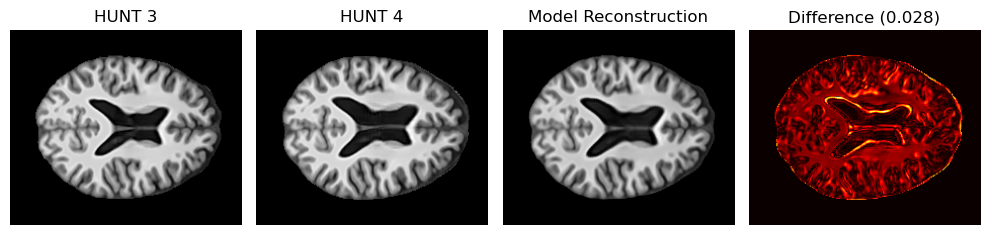

Displaying snapshot from pair 2000


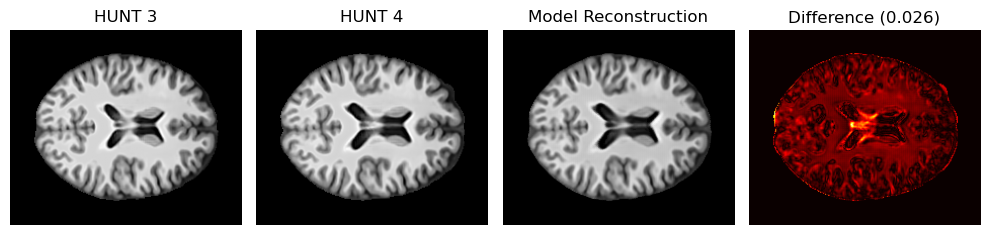

Displaying snapshot from pair 2400


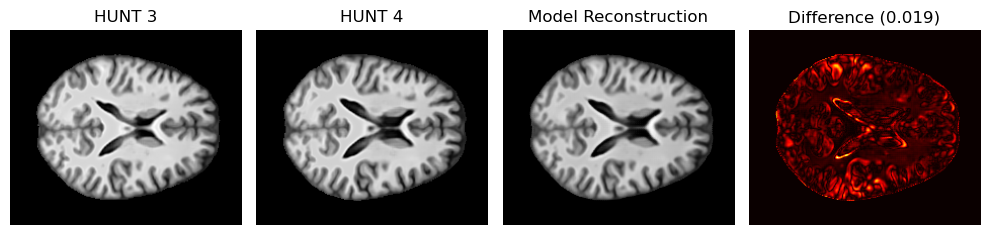

Displaying snapshot from pair 2800


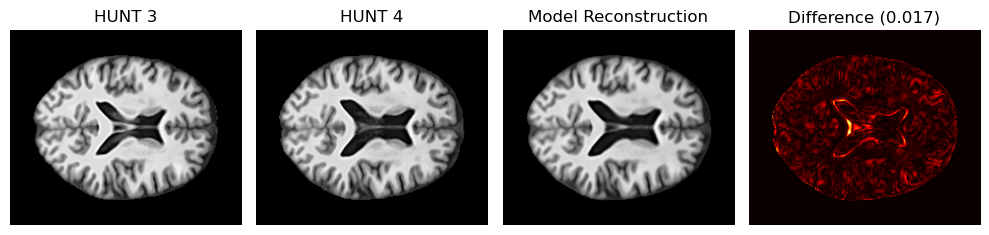

Displaying snapshot from pair 3200


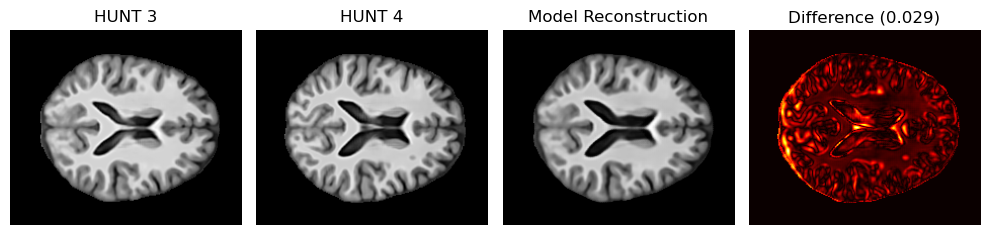

Displaying snapshot from pair 3600


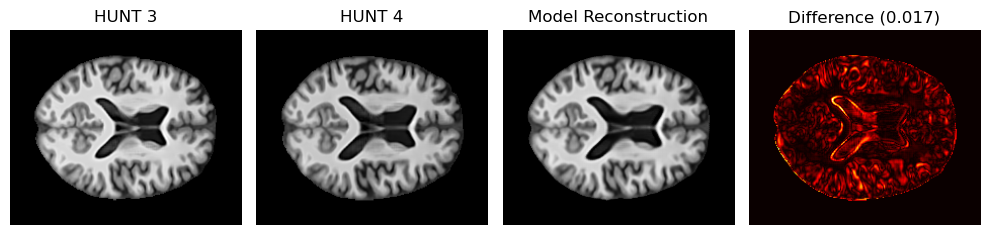

Displaying snapshot from pair 4000


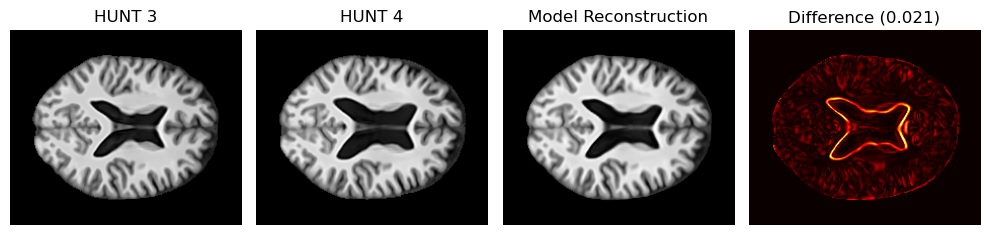

In [10]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [32]:
# Save the final model to /out directory
output_dir = "out/mpgan_3d"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "3d_mpgan_D_2.5.pt")
torch.save(D.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/mpgan_3d/3d_mpgan_D_2.5.pt
